# Fit nonlinear function to network performance

This script takes in the results from data-overview.ipynb, and performs a regression to extract the impact of different regulatory parameters on the data.

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.backends.backend_pdf import PdfPages

import matplotlib as mpl
import matplotlib.ticker as ticker

import numpy as np
import pandas as pd
import os
import plotly.graph_objects as go
import plotly.express as px
import pickle
import time

# import clustering packages
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import DotProduct, WhiteKernel
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline, interp1d
from scipy.signal import savgol_filter

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'
from tqdm import tqdm
from joblib import Parallel, delayed

from stoch_sim_model import *

In [2]:
# Load data from 2nd infections
reg_model = ''
runs = '-1-'
comment = "acute_all-sparse-reg"
d = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'
d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/processed_full_data'+runs+'runs'+'-'+comment+'.pkl'
# d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/processed_data'+runs+'runs'+'-'+comment+'.pkl'

# Import datasets
clustered_mean_df = pd.read_pickle(d_mean)
# '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/list_processed_data'+runs+'runs'+'-'+comment+'.pkl'
with open('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/list_processed_full_data'+runs+'runs'+'-'+comment+'.pkl', 'rb') as f:
    infection_scenarios = pickle.load(f)

with pd.option_context('display.max_columns', None):
    display(clustered_mean_df)

,b_I,d_I,K_I,I_0,S_0,N_0,d_S,K_H,psi_myc_I,psi_myc_HI,psi_myc_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_Edie_I,psi_Edie_HI,psi_Edie_HE,L0_Edie,harm_pI,harm_pS,max_eM_fold,frac_cM,log_T_pEcyteM,T_min_pI,T_max_pI,T_pE_start,T_pE_clear,stim_pI,stim_pHI,stim_pHE,scaled_min_pS,antigenicity_over_harm,harm_pI_noprotection,peff_clearance,peff_toxicity,peff_protection
0,1.500000e-07,0.15,10000.0,1000.0,10000000.0,100.0,0.01,100000.0,-1.581044,0.512725,0.012887,-0.571281,1.082445,0.680312,1.990731,0.852721,0.0,0.0,0.0,-27.0,-1.781470,-1.820803,-1.623768,-0.823612,1.386375e+07,0.000000e+00,0.0,0.000000,0.0,0.000,8.688,60.000,-60.000,6.526541,1.793700,0.000000,0.015033,3.349148,1.386375,0.000000,0.000000,0.000000
1,1.500000e-07,0.15,10000.0,1000.0,10000000.0,100.0,0.01,100000.0,-1.581044,0.512725,0.012887,-0.571281,1.082445,0.680312,1.990731,0.852721,0.0,0.0,0.0,-27.0,-0.198678,-1.297593,1.292021,-1.086182,1.386375e+07,0.000000e+00,0.0,0.000000,0.0,0.000,8.688,60.000,-60.000,6.526541,1.793700,0.000000,0.015033,3.349148,1.386375,0.000000,0.000000,0.000000
2,1.500000e-07,0.15,10000.0,1000.0,10000000.0,100.0,0.01,100000.0,-1.581044,0.512725,0.012887,-0.571281,1.082445,0.680312,1.990731,0.852721,0.0,0.0,0.0,-27.0,0.138821,0.617252,1.967829,-2.455158,1.386375e+07,0.000000e+00,0.0,0.000000,0.0,0.000,8.688,60.000,-60.000,6.526541,1.793700,0.000000,0.015033,3.349148,1.386375,0.000000,0.000000,0.000000
3,1.500000e-07,0.15,10000.0,1000.0,10000000.0,100.0,0.01,100000.0,-1.581044,0.512725,0.012887,-0.571281,1.082445,0.680312,1.990731,0.852721,0.0,0.0,0.0,-27.0,0.399241,0.654001,0.074303,-2.149283,1.386375e+07,0.000000e+00,0.0,0.000000,0.0,0.000,8.688,60.000,-60.000,6.526541,1.793700,0.000000,0.015033,3.349148,1.386375,0.000000,0.000000,0.000000
4,1.500000e-07,0.15,10000.0,1000.0,10000000.0,100.0,0.01,100000.0,-1.581044,0.512725,0.012887,-0.571281,1.082445,0.680312,1.990731,0.852721,0.0,0.0,0.0,-27.0,-1.190272,-1.461508,0.987995,1.409015,1.386375e+07,0.000000e+00,0.0,0.000000,0.0,0.000,8.688,60.000,-60.000,6.526541,1.793700,0.000000,0.015033,3.349148,1.386375,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14624995,1.000000e-01,0.01,100000000.0,500000.0,10000000.0,1000.0,0.01,100000.0,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,-3.000000,0.0,0.0,0.0,-27.0,2.000000,1.000000,2.000000,0.000000,2.219945e+07,9.128536e+05,0.0,0.878188,0.0,0.000,60.000,0.156,59.844,0.106654,0.843996,0.221588,0.109848,3.172940,2.407050,0.187106,0.091285,0.039808
14624996,1.000000e-01,0.01,100000000.0,500000.0,10000000.0,1000.0,0.01,100000.0,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,-3.000000,0.0,0.0,0.0,-27.0,2.000000,1.000000,2.000000,1.500000,2.405886e+07,5.398717e+03,0.0,0.885254,0.0,0.000,60.000,0.216,-0.216,0.115820,0.923128,0.005470,0.101262,3.172940,2.407050,0.001165,0.000540,0.000260
14624997,1.000000e-01,0.01,100000000.0,500000.0,10000000.0,1000.0,0.01,100000.0,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,-3.000000,0.0,0.0,0.0,-27.0,2.000000,1.000000,2.000000,3.000000,2.406400e+07,3.008914e+03,0.0,0.883127,0.0,0.000,60.000,0.156,-0.156,0.115843,0.923338,0.003882,0.101227,3.172940,2.407050,0.000650,0.000301,0.000145
14624998,1.000000e-01,0.01,100000000.0,500000.0,10000000.0,1000.0,0.01,100000.0,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,-3.000000,0.0,0.0,0.0,-27.0,2.000000,2.000000,-2.000000,-3.000000,1.071394e+06,1.469412e+07,0.0,0.873047,0.0,11.076,4.104,0.156,59.844,0.007213,0.284192,3.480325,0.001563,3.172940,2.407050,2.299911,1.469412,0.345028


In [3]:
# Define parameters
num_categories = len(perf_vars)
num_modules = len(modules)
num_psis = len(Na_reg)

module_reg = {'Na': [r for r in Na_reg if np.std(infection_scenarios[10][r].values) > 0], 
              'NE': [r for r in NE_reg if np.std(infection_scenarios[10][r].values) > 0],  
              'EE': [r for r in EE_reg if np.std(infection_scenarios[10][r].values) > 0]}

module_reg_labels = {'Na': [r for i, r in enumerate(param_names[-16:-12]) if  Na_reg[i] in module_reg['Na']], 
                     'NE': [r for i, r in enumerate(param_names[-12:-8]) if  NE_reg[i] in module_reg['NE']],
                     'EE': [r for i, r in enumerate(param_names[-4:]) if  EE_reg[i] in module_reg['EE']]}
reg_label = param_names[-16:-12] + param_names[-12:-8] + param_names[-4:]
signal_classes = [r for i, r in enumerate(["Ag.", "Inf. harm", "Resp. harm", "Baselines"]) if np.std(infection_scenarios[0][[Na_reg[i]] + [NE_reg[i]] + [EM_reg[i]] + [EE_reg[i]]].values) > 0]

reg = [r for r in Na_reg + NE_reg + EE_reg if np.std(infection_scenarios[10][r].values) > 0]
key_var = 'antigenicity_over_harm'
n_virs = len(infection_scenarios)
cmap_colors = sns.color_palette('tab20c', 20)
tol = 1e-2

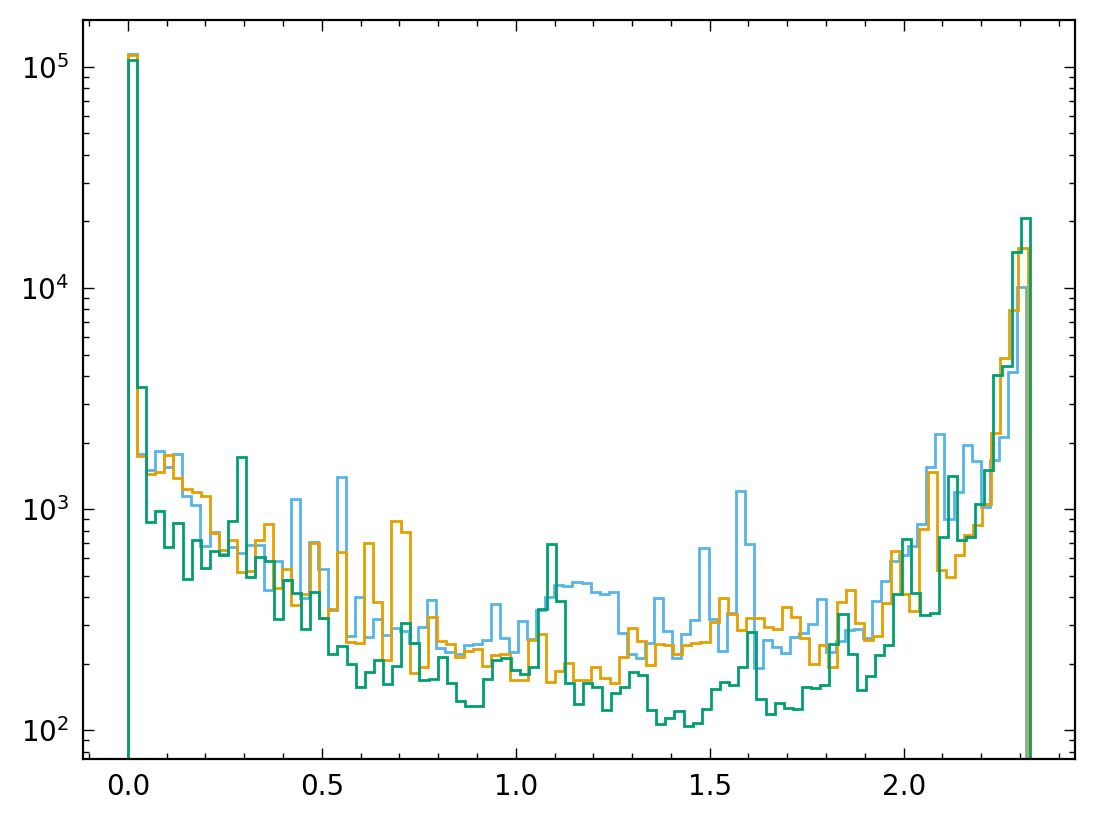

In [4]:
# Inspect distribution of observables
sel = 'peff_clearance'
for a in np.unique(clustered_mean_df.loc[(clustered_mean_df.b_I == b_C)][key_var].values):
    data = clustered_mean_df.loc[clustered_mean_df[key_var] == a]
    plt.hist(data[sel], bins = np.linspace(np.amin(data[sel]), np.amax(data[sel]), 100), histtype = 'step', log = True);

,antigenicity_over_harm,stim_pI,stim_pHI,stim_pHE
0,0.532046,0.000100,0.003307,3.284218
1,0.544286,0.002457,0.159179,3.317682
2,0.556817,0.009260,0.474249,3.298233
3,0.562162,0.000164,0.003307,3.308033
4,0.569737,0.020708,0.815945,3.306952
...,...,...,...,...
223,3.120998,6.309190,2.026831,3.360314
224,3.172940,0.115872,0.923593,3.677622
225,3.349148,6.526541,1.793700,3.489742
226,5.611731,0.801340,0.923593,3.917466


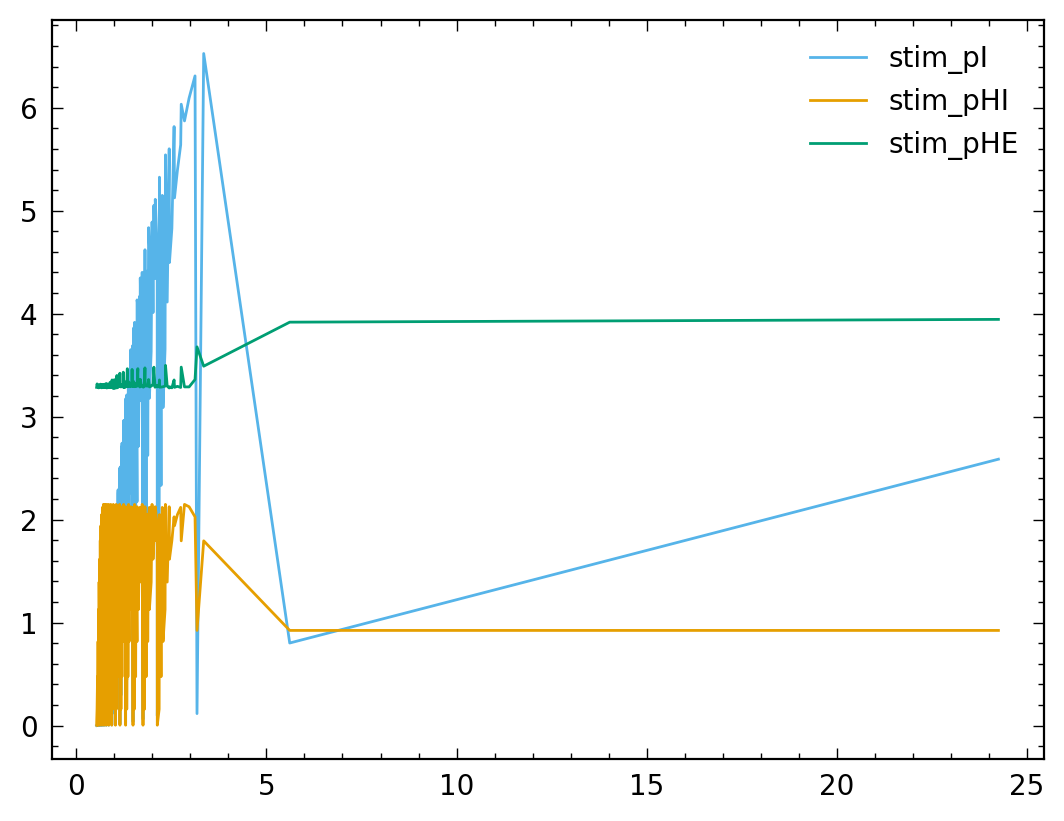

In [5]:
#norm_stim = clustered_mean_df.loc[(np.sum(np.abs(clustered_mean_df[reg_stim]), axis = 1) == 0)].groupby(key_var, as_index = False).mean()[[key_var, 'stim_pI', 'stim_pHI', 'stim_pHE']]
norm_stim = clustered_mean_df.groupby(key_var, as_index = False).max()[[key_var, 'stim_pI', 'stim_pHI', 'stim_pHE']]
with pd.option_context('display.max_columns', None):
    display(norm_stim)
    
plt.plot(norm_stim[key_var], norm_stim[['stim_pI', 'stim_pHI', 'stim_pHE']], label = ['stim_pI', 'stim_pHI', 'stim_pHE'])
plt.legend()

In [6]:
# # Explore noise in the data
# fig, axs = plt.subplots(1, len(perf_vars), 
#                               figsize=(len(perf_vars)**2 - len(perf_vars), 4), sharex=True, sharey=False)


# data_mean = clustered_mean_df.groupby(reg + vir_vars, as_index = False).std()
        
# for i, var in enumerate(perf_vars):
#     im = axs[i].scatter(data_mean[reg_choice[j]]/np.amax(data_mean[reg_choice[j]]), 
#                         (10**data_mean[var] - 1) if i == 4 or i == 5 else data_mean[var], 
#                       marker = 's', s = 50, color = cmap_colors[module_index*len(reg_choice) + j], 
#                         edgecolors = 'None',label = reg_label[module_index*len(reg_choice) + j ])

#     if module_index + j == 0: 
#         axs[i].minorticks_off()
#         axs[i].yaxis.set_tick_params(labelbottom=True)
#         axs[i].xaxis.set_tick_params(labelbottom=True)
#         axs[i].tick_params(axis='both', which='major', labelsize=8)
#         axs[i].set_box_aspect(1)
#         axs[i].locator_params(axis='y', nbins=4)
#         axs[i].locator_params(axis='x', nbins=4)
#         axs[i].set_ylabel("St. dev.\n"+perf_labels[i], fontsize = 12)
#         axs[i].set_xlabel(r'Design variables,$\{\vec\psi, \vec L_0 \}$', fontsize = 12)

# axs[-1].legend(bbox_to_anchor=(1.1, 1), fontsize=10, framealpha=0, ncol = 2)
# fig.subplots_adjust(wspace=.4, hspace=.35)
# #plt.savefig('_figs/'+comment+'-'+'mean_regulation_trends_by_performance'+'.png', dpi=150, bbox_inches="tight")

### Fit model to average data
The nonlinear sigmoid model does a good job on the data averaged over infections and marginalized over modules. This is the minimum we require.

fevals: 16
fevals: 88
fevals: 26
fevals: 23
fevals: 8
fevals: 8
fevals: 8
fevals: 52
fevals: 47
fevals: 39
fevals: 32
fevals: 14


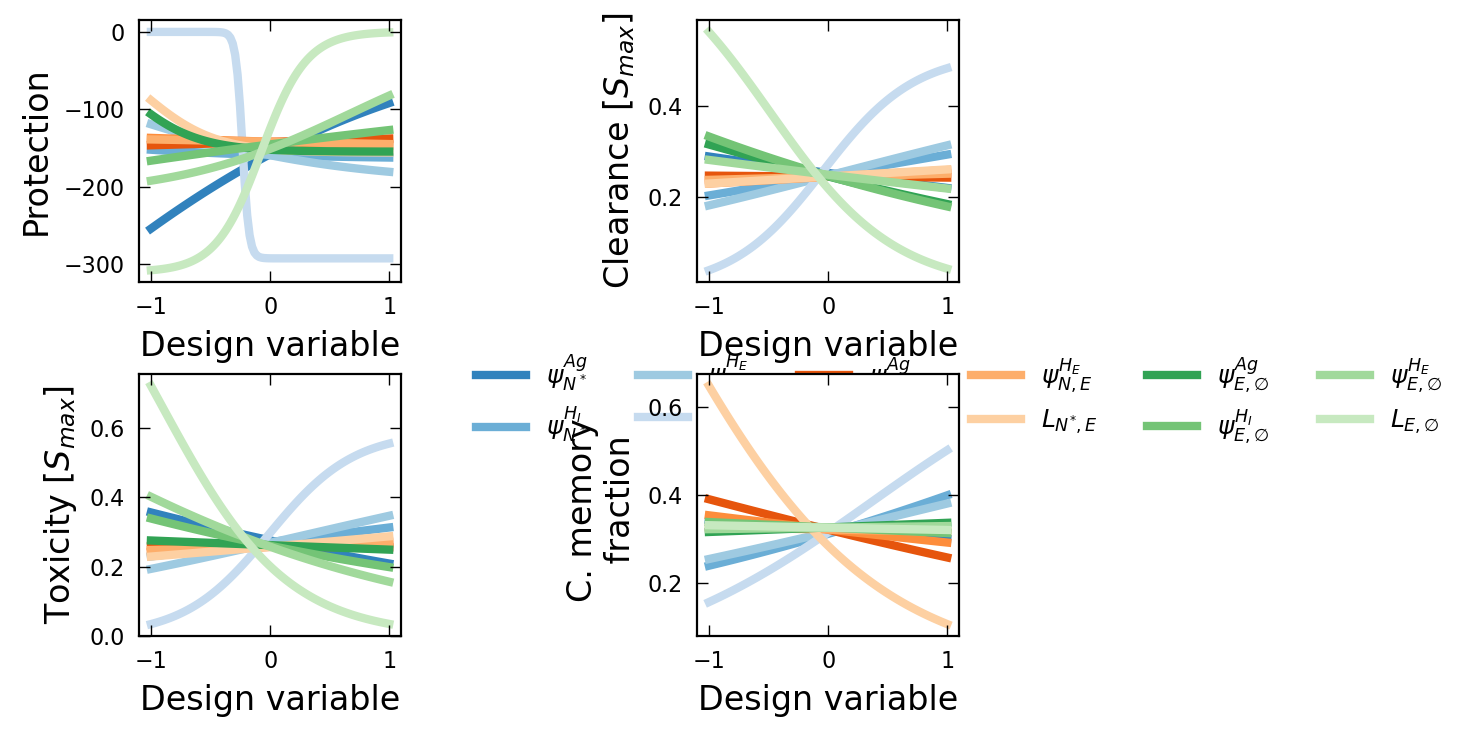

In [7]:
# Fit impact of regulatory parameters on performace: marginalizing over modules
fig, axs = plt.subplots(2, len(perf_vars) // 2, 
                              figsize=(len(perf_vars) + 2, len(perf_vars)), sharex=True, sharey=False)

for module_index in np.arange(0, len(modules)):
    reg_choice_label = modules[module_index]
    reg_choice = module_reg[reg_choice_label]
    zero_regs = np.concatenate([(module_reg[modules[u]] if u != module_index else []) for u in np.arange(0, len(modules))]).tolist()
    
    x_varname= key_var

    for j, p in enumerate(signal_classes):
        data_mean = clustered_mean_df.groupby(reg_choice[j], as_index = False).mean()
        
        for i, (var, ax) in enumerate(zip(perf_vars, axs.flat)):
            # im = ax.scatter(data_mean[reg_choice[j]]/np.amax(data_mean[reg_choice[j]]), 
            #                     (10**data_mean[var] - 1) if i == 4 or i == 5 else data_mean[var], 
            #                   marker = 's', s = 50, color = cmap_colors[module_index*len(reg_choice) + j], 
            #                     edgecolors = 'None',label = reg_label[module_index*len(reg_choice) + j ])

            y_max = np.max(data_mean[var].values)
            y_min = np.min(data_mean[var].values)
            y_std = np.std(data_mean[var].values)

            popt, pcov, infodict, _, _ = curve_fit(sigmoid_1d, data_mean[reg_choice[j]].values, data_mean[var].values, 
                                   p0 =(y_max, y_min, 0.0, 0.0),
                                   method = 'trf', 
                                   bounds = ([y_max - tol*y_std, np.minimum(2*y_min, 0), -4*L0_max, -4*L0_max], 
                                             [2*y_max if y_max > 0 else y_std*tol, np.maximum(y_min, 0) + y_std*tol, 4*L0_max, 4*L0_max]),
                                   maxfev=10000,
                                   full_output = True)

            x = np.linspace(-np.max(data_mean[reg_choice[j]]), np.max(data_mean[reg_choice[j]]), 100)
            ax.plot(x/np.amax(x), (10**sigmoid_1d(x, *popt) - 1) if i == 4 or i == 5 else sigmoid_1d(x, *popt), 
                        linestyle='-',
                        linewidth = 3.0,
                        color = cmap_colors[module_index*len(reg_choice) + j],
                        label = reg_label[module_index*len(reg_choice) + j ],
                        zorder = 0)

            if i == 0:
                print("fevals:", infodict['nfev'])

            if module_index + j == 0: 
                ax.minorticks_off()
                ax.yaxis.set_tick_params(labelbottom=True)
                ax.xaxis.set_tick_params(labelbottom=True)
                ax.tick_params(axis='both', which='major', labelsize=8)
                ax.set_box_aspect(1)
                ax.locator_params(axis='y', nbins=4)
                ax.locator_params(axis='x', nbins=4)
                ax.set_ylabel(perf_labels[i], fontsize = 12)
                ax.set_xlabel(r'Design variable', fontsize = 12)

axs[0,1].legend(loc='lower center', bbox_to_anchor=(1.0, -0.71), fontsize=9, framealpha=0, ncol=len(reg_label) // 2)

#legend(bbox_to_anchor=(1.1, 1), fontsize=12, framealpha=0, ncol = 2)
fig.subplots_adjust(wspace=.5, hspace=.35)
plt.savefig('_figs/'+comment+'-'+'mean_regulation_trends_by_performance'+'.png', dpi=300, bbox_inches="tight")

In [8]:
del clustered_mean_df

### Fit model to individual infection scenarios and with all regulatory modules as variables

In [9]:
# Regress Performance measures on regulation parameters
num_cpu = 145
variables = reg
tol = 1e-2

def model(input, fit = "non-linear"):

    out = []
    infection = input[vir_vars].values[0]
    runtimes = str(np.round(infection, 3))+': '
    
    for i, perf in enumerate(perf_vars):
        # run regression
        start = time.time() # timestamp start
        
        if fit == "linear":
            input.loc[:,'dep_var'] = np.log(1 + input[perf].values) if 'Memory' in perf_labels[perf_vars.index(perf)] or 'magnitude' in perf_labels[perf_vars.index(perf)] else input[perf].values
            lr = smf.ols('dep_var ~ ' + ' + '.join(variables), data=input).fit()
    
            # save values
            out.append( (lr.params.values[0: 1 + len(variables)]).tolist() + np.sqrt(np.diag(lr.cov_params())).tolist() + infection.tolist() + [np.mean(input[perf].values), i] )
        else:
            y_max = np.max(input[perf].values)
            y_min = np.min(input[perf].values)
            y_std = np.std(input[perf].values)
            popt, pcov = curve_fit(sigmoid, input[variables].values, input[perf].values, 
                           p0 =[y_max, y_min] + len(variables)*[0.0] + num_modules*[0.0],
                           method = 'trf', 
                           bounds = ([y_max - y_std*tol, np.minimum(0.0, y_min)] + len(variables)*[-15*L0_max] + num_modules*[-15*L0_max], 
                                     [1.0 if perf == "frac_cM" else (y_max + y_std*tol), y_min + y_std*tol] + len(variables)*[15*L0_max] + num_modules*[15*L0_max]), 
                                   maxfev=100000,
                                   full_output = False)
            
            residuals = input[perf].values - sigmoid(input[variables].values, *popt)
            rmse = np.sqrt(np.mean(residuals**2))
            out.append(popt.tolist() + np.sqrt(np.diag(pcov)).tolist() + infection.tolist() + [np.mean(input[perf].values), 
                                                                                               np.max(input[perf].values), 
                                                                                               np.min(input[perf].values), 
                                                                                               np.median(input[perf].values), 
                                                                                               i, rmse, y_std, 
                                                                                               np.amax(input['scaled_min_pS'].values),
                                                                                               input['harm_pI_noprotection'].values[0],
                                                                                               np.amax(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pI'].values), 
                                                                                               np.amax(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pHI'].values),
                                                                                               np.amax(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pHE'].values)])

            # if i == 0:
            #     print("fevals:", infodict['nfev'])
        end = time.time() # timestamp start
        runtimes += (perf+ ' = ' + str((end - start)/3600)+' hrs, ')
        
    #print(runtimes)
    out_data = pd.DataFrame(np.vstack(out), 
                            columns = ['y_max', 'y_min'] \
                            + variables + [('intercept_' + j) for j in modules] \
                            + ['sigma_y_max', 'sigma_y_min'] + ['sigma_'+r  for r in variables] \
                            + [('sigma_intercept_' + j) for j in modules] \
                            + vir_vars \
                            + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'max_scaled_min_pS', 'harm_pI_noprotection', 'stim_pI', 'stim_pHI', 'stim_pHE'])
    out_data['antigenicity_over_harm'] = antigenicity_over_harm(out_data)
    out_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'+comment+runs+'fit_'+str(np.round(infection, 3))+'.pkl')
    
    return np.vstack(out)

# Compile datasets
impact_data = pd.DataFrame(np.vstack(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(model)(input = data.groupby(vir_vars + variables, as_index=False).mean(), fit = "nonlinear") 
                                                                                                            for data in infection_scenarios)), 
                            columns = ['y_max', 'y_min'] \
                            + variables + [('intercept_' + j) for j in modules] \
                            + ['sigma_y_max', 'sigma_y_min'] + ['sigma_'+r  for r in variables] \
                            + [('sigma_intercept_' + j) for j in modules] \
                            + vir_vars \
                            + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'max_scaled_min_pS', 'harm_pI_noprotection', 'stim_pI', 'stim_pHI', 'stim_pHE'])
impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')

In [10]:
# # IF the above fails: Compile datasets
# num_cpu = 150
# file_list = [f for f in os.listdir(d) if comment in f]
# num_files = len(file_list)

# def import_fits(f,d):
    
#     file_path = os.path.join(d, f)
#     with open(file_path, 'rb') as filename:  
#         out = pickle.load(filename)

#     return out

# impact_data = pd.concat(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(import_fits)(f = file_name, d = d) 
#                                                                                                             for file_name in file_list))
# impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

# impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')

In [11]:
# View result
perf_choice = 1 # chose observable
impact_data = pd.read_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')
with pd.option_context('display.max_columns', None,'display.max_rows', None):
    display(impact_data.loc[(impact_data.perf_index == perf_choice)])

,y_max,y_min,psi_myc_I,psi_myc_HI,psi_myc_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_Edie_I,psi_Edie_HI,psi_Edie_HE,L0_Edie,intercept_Na,intercept_NE,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_myc_I,sigma_psi_myc_HI,sigma_psi_myc_HE,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_HI,sigma_psi_NE_HE,sigma_L0_NE,sigma_psi_Edie_I,sigma_psi_Edie_HI,sigma_psi_Edie_HE,sigma_L0_Edie,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EE,d_I,K_I,b_I,K_H,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,max_scaled_min_pS,harm_pI_noprotection,stim_pI,stim_pHI,stim_pHE,antigenicity_over_harm
1,1.390729e+00,5.875269e-03,4.170458,0.060936,0.362687,3.292249,0.529663,0.016788,-0.053182,0.968615,-4.221856,-0.401892,-0.357016,-2.316606,2.781335,4.859589,-0.412975,3.378062e-03,1.306666e-03,4.460564e-02,9.308931e-03,1.352808e-02,3.523214e-02,2.986035e-02,2.582051e-02,2.670740e-02,6.161187e-02,4.891112e-02,1.147558e-02,1.119572e-02,2.811866e-02,3.526298e-02,1.916161e-01,9.975037e-03,0.150000,1.000000e+04,1.500000e-07,100000.0,100.0,10000000.0,1000.0,4.140155e-01,1.384854e+00,0.000000e+00,0.000788,1.0,2.244262e-01,5.875358e-01,0.959750,1.386375,6.526541,1.793700,3.065723,3.349148
5,1.390427e+00,5.154449e-03,3.559377,0.050587,0.358071,3.230505,0.476374,0.042215,-0.118248,0.950566,-3.784731,-0.368611,-0.358769,-2.468829,2.685294,4.774032,-0.369835,3.330744e-03,1.277257e-03,3.876130e-02,9.128774e-03,1.221177e-02,3.298734e-02,2.864608e-02,2.510648e-02,2.617550e-02,5.901857e-02,4.829093e-02,1.009161e-02,1.012039e-02,3.156759e-02,3.177818e-02,1.834847e-01,9.426437e-03,0.150000,1.637894e+04,1.500000e-07,100000.0,100.0,10000000.0,1000.0,4.129168e-01,1.384588e+00,0.000000e+00,0.000721,1.0,2.193786e-01,5.839010e-01,0.928953,1.386375,6.034064,1.793700,3.103571,2.758122
9,1.389985e+00,5.797200e-03,3.077432,0.035944,0.374530,3.234315,0.386215,0.020609,-0.117780,1.015808,-3.373931,-0.398577,-0.458851,-2.598745,2.593309,4.979117,-0.471404,3.154885e-03,1.214944e-03,3.568583e-02,9.767861e-03,1.223945e-02,3.248250e-02,2.855003e-02,2.603449e-02,2.714528e-02,6.643041e-02,3.952126e-02,1.012317e-02,1.072284e-02,2.899737e-02,3.022177e-02,2.044886e-01,9.390143e-03,0.150000,2.682696e+04,1.500000e-07,100000.0,100.0,10000000.0,1000.0,4.085451e-01,1.384188e+00,0.000000e+00,0.000666,1.0,2.109329e-01,5.797201e-01,0.862845,1.386375,5.542180,1.793700,3.117143,2.344404
13,1.389571e+00,5.761389e-03,2.064215,0.127489,0.418078,3.535786,0.299059,0.049650,-0.133142,1.070205,-2.932069,-0.419746,-0.592451,-2.783885,2.535263,5.193511,-0.619527,3.016506e-03,1.132853e-03,2.538558e-02,1.200245e-02,1.468741e-02,3.742613e-02,2.943678e-02,2.758940e-02,2.885991e-02,7.571147e-02,3.247844e-02,1.050912e-02,1.204081e-02,2.939762e-02,3.238814e-02,2.317113e-01,9.519464e-03,0.150000,4.393971e+04,1.500000e-07,100000.0,100.0,10000000.0,1000.0,4.015345e-01,1.383809e+00,0.000000e+00,0.000580,1.0,2.033549e-01,5.761389e-01,0.845515,1.386375,5.051265,1.793700,3.120052,2.038612
17,1.389128e+00,5.723397e-03,1.833822,0.176825,0.641321,4.194785,0.245713,0.016148,-0.116950,1.090965,-2.639337,-0.403770,-0.719262,-3.031873,2.782718,5.288067,-0.779070,2.735312e-03,1.002471e-03,2.586753e-02,1.220663e-02,1.599100e-02,5.092933e-02,2.821123e-02,2.686140e-02,2.805676e-02,7.611749e-02,2.740231e-02,1.007321e-02,1.197760e-02,2.963104e-02,3.869835e-02,2.324115e-01,9.257482e-03,0.150000,7.196857e+04,1.500000e-07,100000.0,100.0,10000000.0,1000.0,3.910766e-01,1.383404e+00,0.000000e+00,0.000500,1.0,1.870720e-01,5.723397e-01,0.798270,1.386375,4.561929,1.793700,3.100940,1.803387
21,1.388067e+00,5.676235e-03,1.616927,0.231574,1.087632,4.653593,0.175344,-0.015889,-0.076780,1.140637,-2.217276,-0.425820,-0.824242,-3.110319,2.801790,5.434213,-0.913548,2.518066e-03,9.056312e-04,2.544093e-02,1.280601e-02,1.995520e-02,5.603362e-02,2.681004e-02,2.604000e-02,2.702836e-02,7.739815e-02,2.147863e-02,9.627080e-03,1.161070e-02,2.761175e-02,3.830900e-02,2.354772e-01,9.029123e-03,0.150000,1.178769e+05,1.500000e-07,100000

#### Check the model goodness of the fit
The model does a pretty good job as the $R^2$ values for clearance, toxicity and memory are above 0.80.

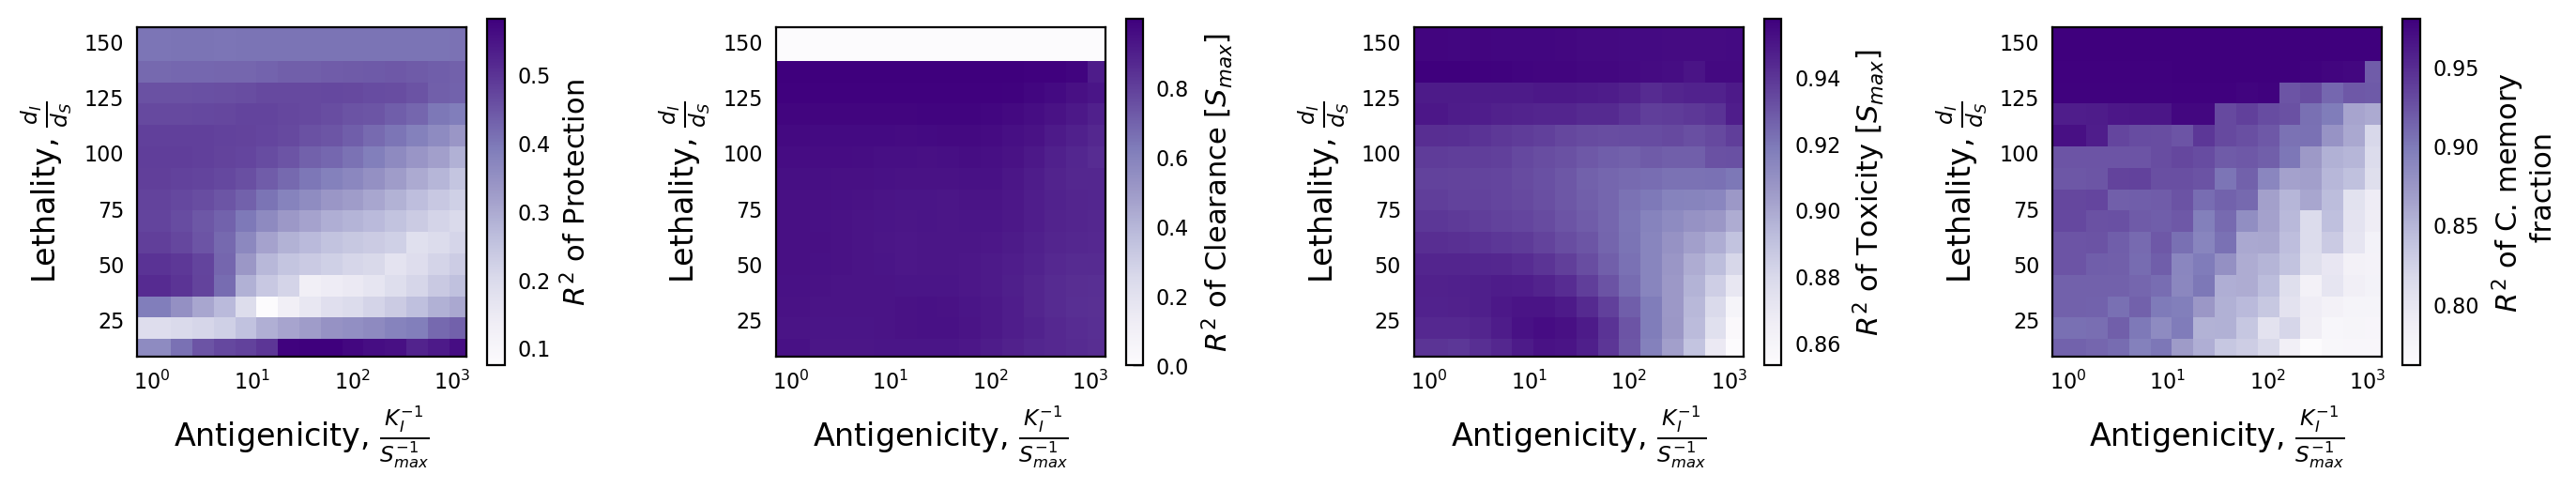

In [12]:
# Examine goodness of fit through R-squared
plots = [vir_vars[1], vir_vars[0]]
plot_labels = ["Antigenicity, "+r"$\frac{K_{I}^{-1}}{S_{max}^{-1}}$", "Lethality, "+r"$\frac{d_{I}}{d_{S}}$"]
size = 3200/np.sqrt(len(infection_scenarios))

fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)*(impact_data.I_0 <= I_min)]
    model_r_sq = (1 - data.rmse**2/data.y_std**2)*(data.y_std > tol)
    z_label = r"$R^2$ of "+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname] if x_varname == 'K_I' else data[x_varname]/d_S,
                                 data['S_0']/data[y_varname] if y_varname == 'K_I' else data[y_varname]/d_S,
                      marker ='s', s = size, c = model_r_sq, cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.55, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-r-squared'+'.png', dpi=150, bbox_inches="tight")

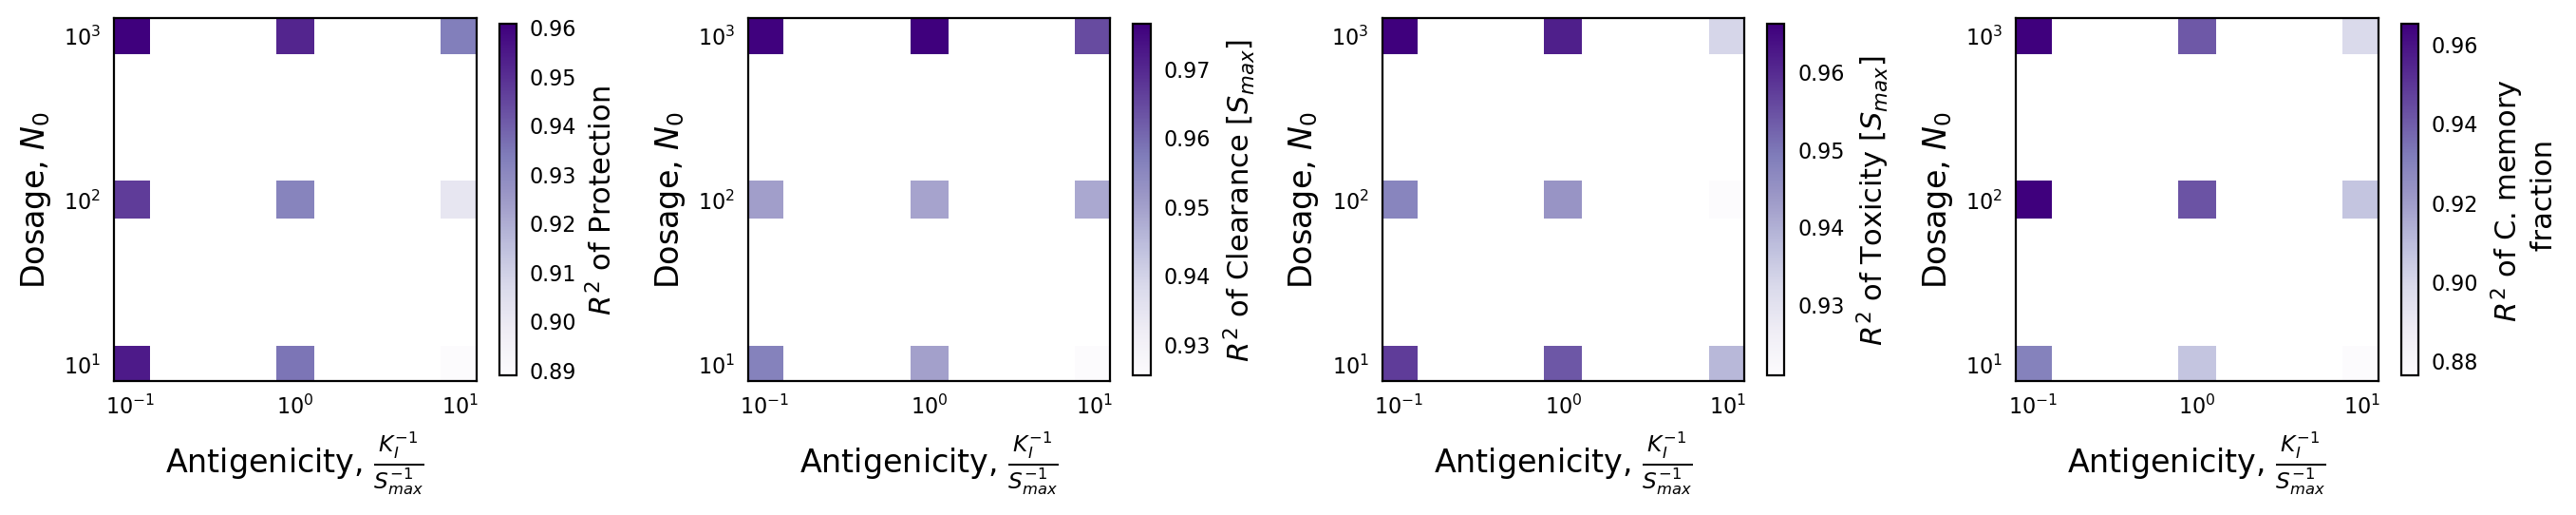

In [13]:
# Examine goodness of fit through R-squared
size = 3200/np.sqrt(len(infection_scenarios))

fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = vir_vars[1], vir_vars[4]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)*(impact_data.I_0 > I_min)]
    model_r_sq = (1 - data.rmse**2/data.y_std**2) #*(data.y_std > tol)
    z_label = r"$R^2$ of "+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname], data[y_varname],
                      marker ='s', s = size, c = model_r_sq, cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    axs[i].semilogx()
    axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.40, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel("Antigenicity, "+r"$\frac{K_{I}^{-1}}{S_{max}^{-1}}$", fontsize = 12)
    ax.set_ylabel("Dosage, "+r"$N_0$", fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-r-squared-cancers'+'.png', dpi=150, bbox_inches="tight")

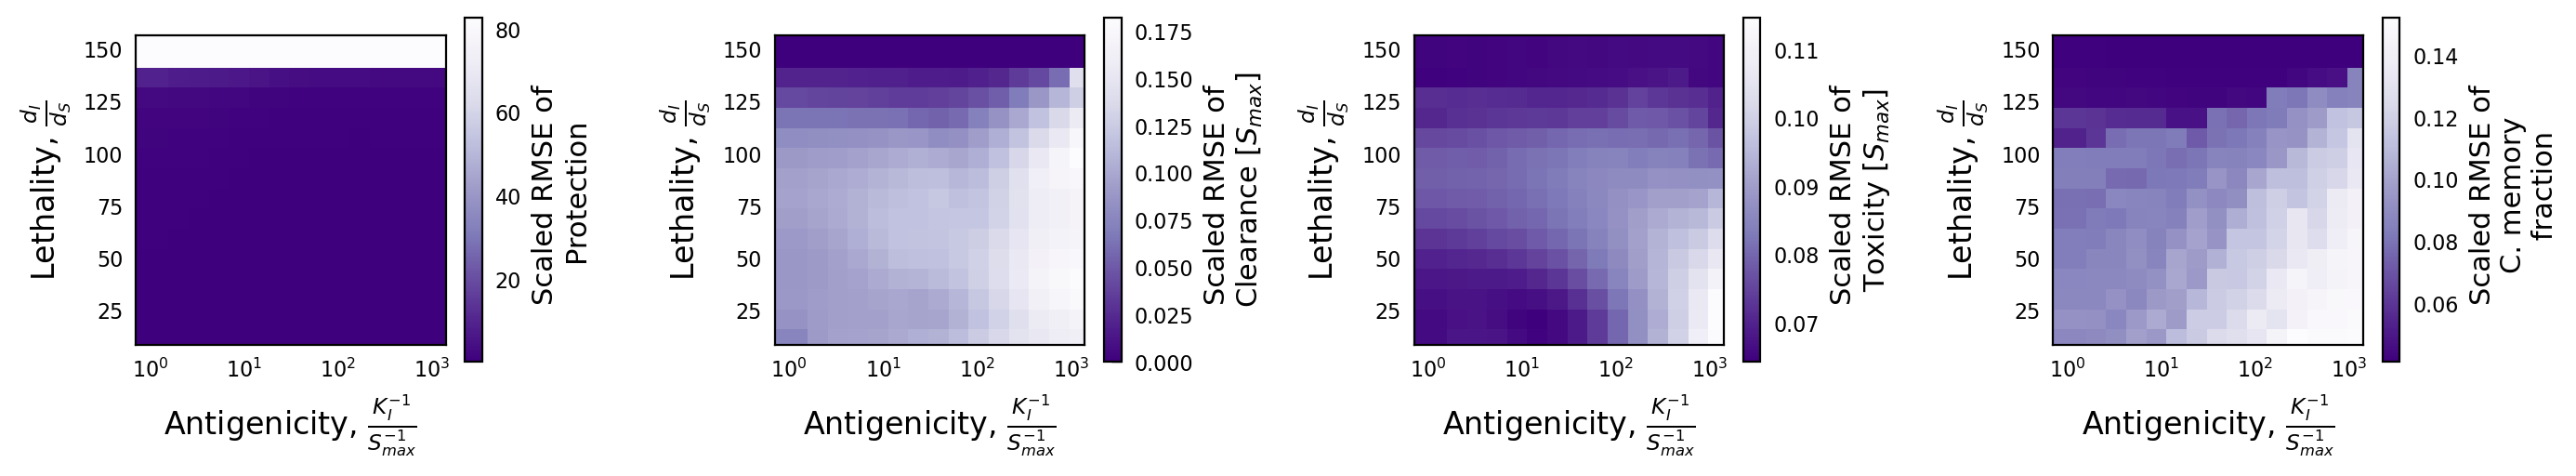

In [14]:
# Examine goodness of fit through scaled-RMSE
fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)*(impact_data.I_0 <= I_min)]
    model_rmse_over_max = (data.rmse/data.y_max)*(data.y_std > tol)
    z_label = "Scaled RMSE of \n"+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname] if x_varname == 'K_I' else data[x_varname]/d_S,
                                 data['S_0']/data[y_varname] if y_varname == 'K_I' else data[y_varname]/d_S,
                      marker ='s', s = size, 
                        c = model_rmse_over_max, cmap='Purples_r', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.65, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-scaled-rmse'+'.png', dpi=150, bbox_inches="tight")

Effector memory expansion appears challenging to fit based on the $R^2$ values. Looks much better when we look at scaled RMSE. Rationalize by observing tha effector memory expansion has non-monotonic dependence on some variables which can lead to a low variance estimate, and make the $R^2$ values look bad.

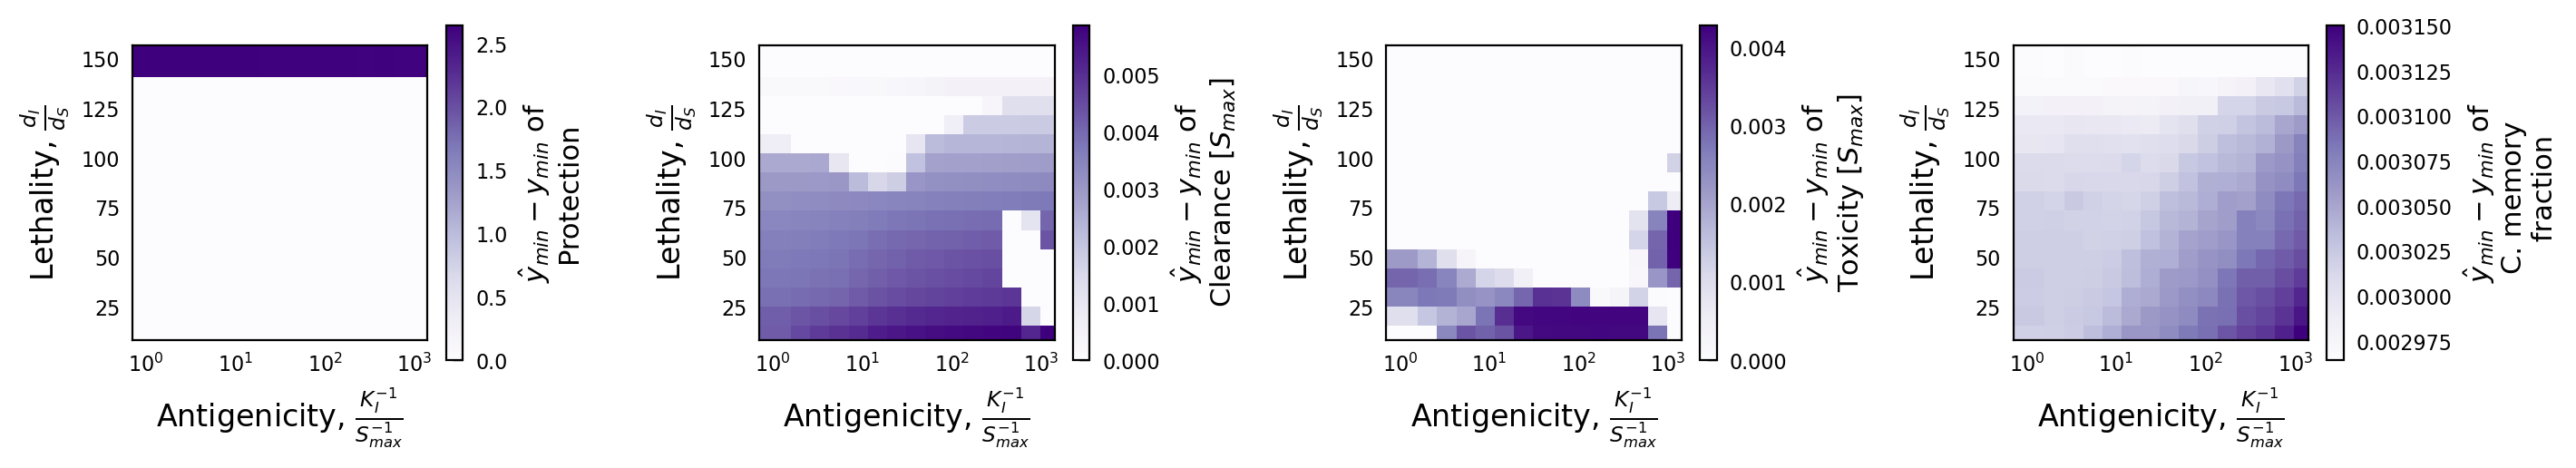

In [15]:
# Examine difference between observed and predicted minima
fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)*(impact_data.I_0 <= I_min)]
    z_label = r"$\hat{y}_{min} - y_{min}$"+ " of\n"+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname] if x_varname == 'K_I' else data[x_varname]/d_S,
                                 data['S_0']/data[y_varname] if y_varname == 'K_I' else data[y_varname]/d_S,
                      marker ='s', s = size, c = (data.y_min - data.min_perf)*(data.y_std > tol), cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.7, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-y_min'+'.png', dpi=150, bbox_inches="tight")

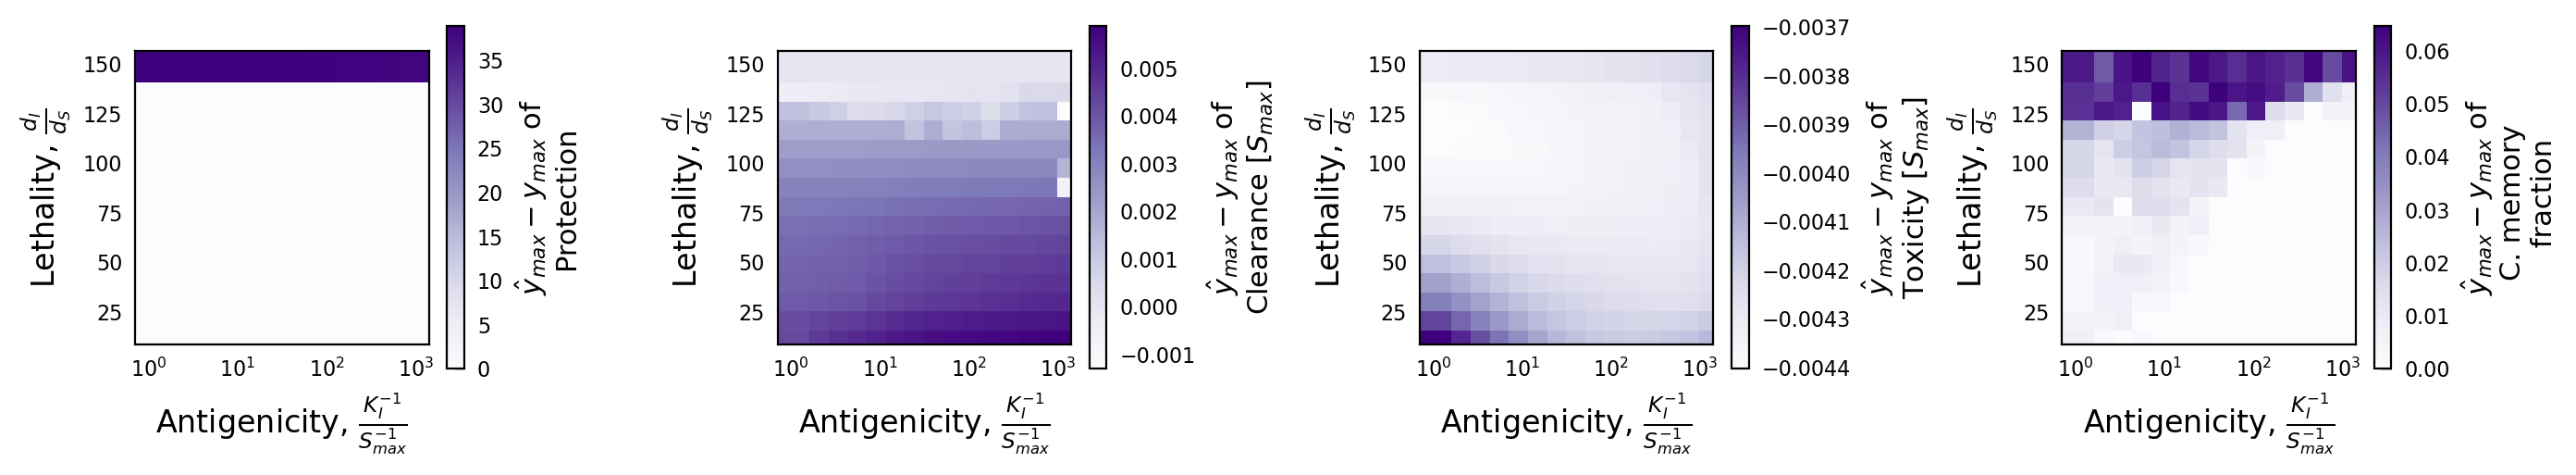

In [16]:
# Examine difference between observed and predicted maxima
plots = [vir_vars[1], vir_vars[0]]

fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)*(impact_data.I_0 <= I_min)]
    z_label = r"$\hat{y}_{max} - y_{max}$ of"+"\n"+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname] if x_varname == 'K_I' else data[x_varname]/d_S,
                                 data['S_0']/data[y_varname] if y_varname == 'K_I' else data[y_varname]/d_S,
                      marker ='s', s = size, c = (data.y_max - data.max_perf)*(data.y_std > tol), cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.75, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-y_max'+'.png', dpi=150, bbox_inches="tight")

The distribution of the values of the bias parameters gives us a sense of how well our simulations can explain variation due to that module. In this case the Naive to Memory module has a computed bias for clearance/toxicity that is at the maximum allowable. However the value is less extreme for memory formation. This suggests a strong bias towards high clearance/toxicity in this module.

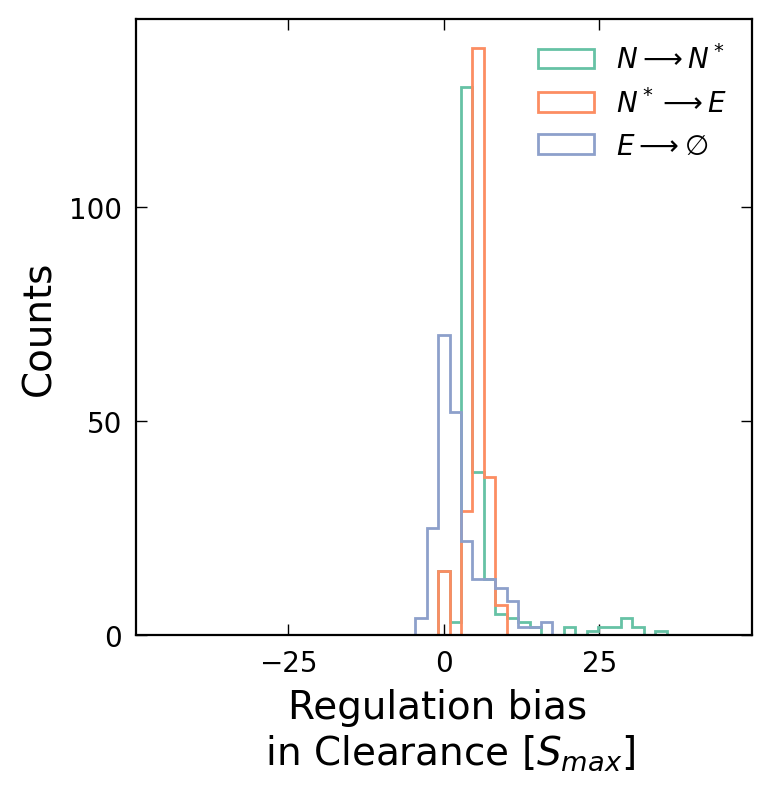

In [17]:
fig, axs = plt.subplots(figsize=(4,4), sharex=False, sharey=False)

cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
for i, r in enumerate(modules):
    data = impact_data[(impact_data.perf_index == perf_choice)*(impact_data.I_0 <= I_min)]['intercept_'+r].values
    axs.hist(data, bins = np.linspace(-15*L0_max, 15*L0_max, 50), histtype = 'step', label = module_labels[i], color = cmap_colors[i], stacked = True);

axs.legend(fontsize = 10, ncol = 1)

axs.set_xlabel("Regulation bias \n in "+perf_labels[perf_choice], fontsize = 14)
axs.set_ylabel("Counts", fontsize = 14)
axs.set_box_aspect(1)
axs.minorticks_off()
axs.locator_params(axis='y', nbins=4)
axs.locator_params(axis='x', nbins=4)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

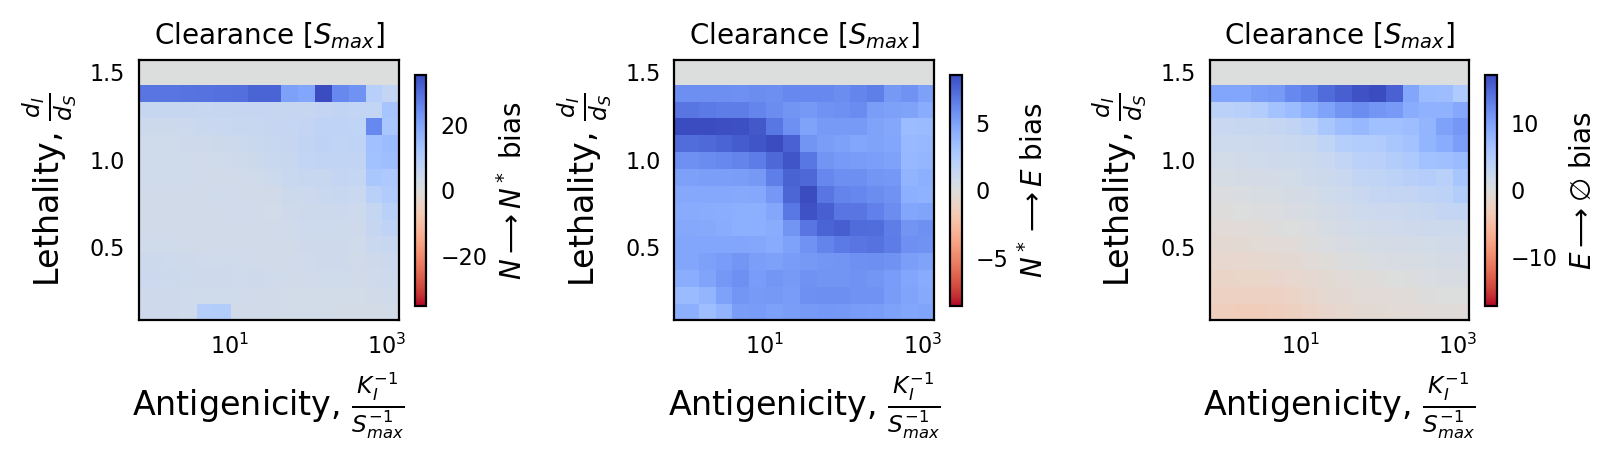

In [18]:
# Visualize optimal regulation
plots = [vir_vars[1], vir_vars[0]]
size = 1250/np.sqrt(len(infection_scenarios))

data = impact_data[(impact_data.perf_index == perf_choice)*(impact_data.I_0 <= I_min)]

fig_c, axs = plt.subplots(1, len(modules), 
                          figsize=(len(modules)**2, 2*len(modules)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, r in enumerate(modules):
    z_varname = 'intercept_'+r
    z_label = module_labels[i]+" bias"
    z = data[z_varname]
    range = np.amax(np.abs(z))
    
    im = axs[i].scatter(S_0/data[x_varname] if x_varname == 'K_I' else data[x_varname],
                                 1/data[y_varname] if y_varname == 'K_I' else data[y_varname],
                      marker ='s', s = size, c = z, cmap='coolwarm_r', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize(vmin = -range, vmax = range))

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)
    axs[i].set_title(perf_labels[perf_choice], fontsize = 10.0)

    cb = fig_c.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.25, pad = 0.05)
    cb.set_label(z_label, fontsize = 10)
    cb.ax.tick_params(labelsize=8)
    
fig_c.subplots_adjust(wspace=.65, hspace=0.5)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

# plt.savefig('_figs/'+comment+'-optimal-reg-average_prot_tox_hmap'+'.png', dpi=150, bbox_inches="tight")

These intercept values are important because they tell you what the value of the observable would be if we ran our processes, without regulation, at half their maximal characteristic rates. A positive value means that the half-max rate leads to above-median performance/cost. It would be useful to convert these to rates.

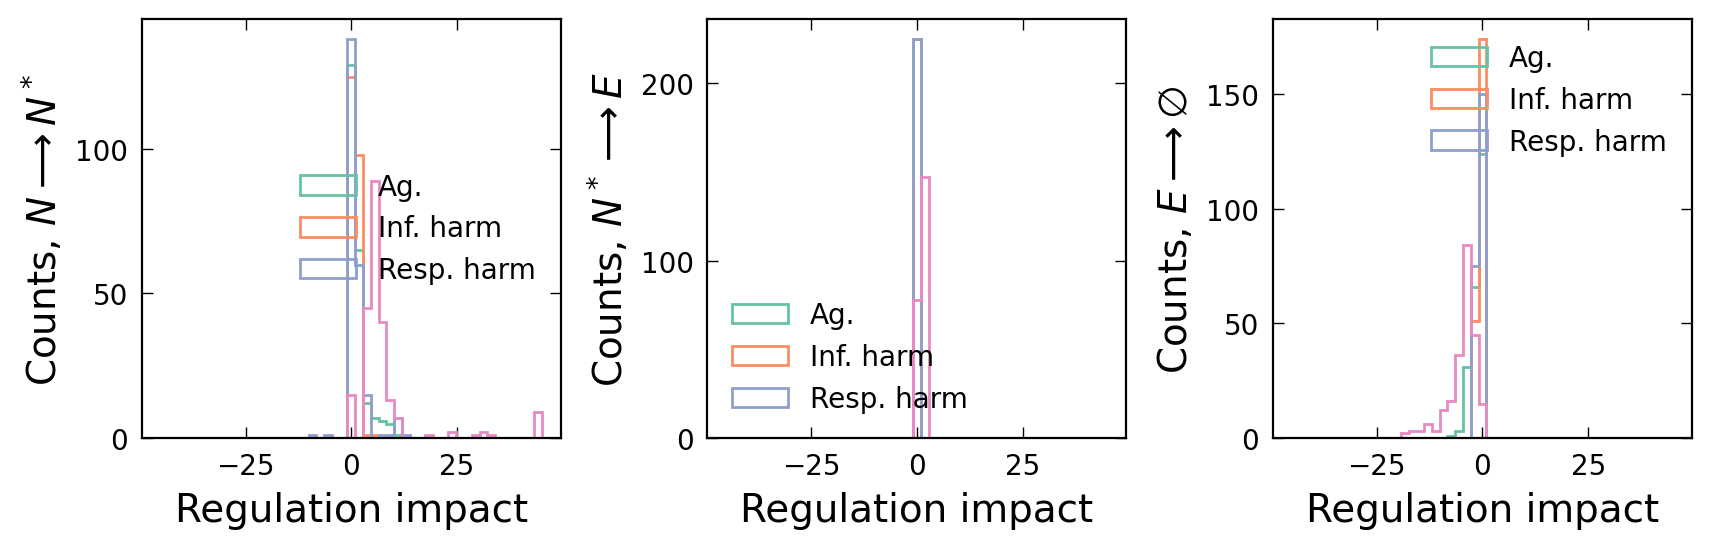

In [19]:
fig, axs = plt.subplots(1,3, figsize=(10,10), sharex=False, sharey=False)

for i, r in enumerate(reg):
    data = impact_data[(impact_data.perf_index == perf_choice)*(impact_data.I_0 <= I_min)][r].values
    module = i // num_psis
    cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
    
    axs[module].hist(data, bins = np.linspace(-15*L0_max, 15*L0_max, 50), histtype = 'step', label = signal_classes[i % num_psis], color = cmap_colors[i % num_psis], stacked = True);

    if (i % num_psis) == num_modules -1:
        axs[module].legend(fontsize = 10, ncol = 1)
    
        axs[module].set_xlabel("Regulation impact", fontsize = 14)
        axs[module].set_ylabel("Counts, "+module_labels[i // num_psis], fontsize = 14)
        axs[module].set_box_aspect(1)
        axs[module].minorticks_off()
        axs[module].locator_params(axis='y', nbins=4)
        axs[module].locator_params(axis='x', nbins=4)

fig.subplots_adjust(wspace=.35, hspace=.25)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

In [20]:
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf_choice)*(impact_data.b_I == 0.0)])

,y_max,y_min,psi_myc_I,psi_myc_HI,psi_myc_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_Edie_I,psi_Edie_HI,psi_Edie_HE,L0_Edie,intercept_Na,intercept_NE,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_myc_I,sigma_psi_myc_HI,sigma_psi_myc_HE,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_HI,sigma_psi_NE_HE,sigma_L0_NE,sigma_psi_Edie_I,sigma_psi_Edie_HI,sigma_psi_Edie_HE,sigma_L0_Edie,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EE,d_I,K_I,b_I,K_H,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,max_scaled_min_pS,harm_pI_noprotection,stim_pI,stim_pHI,stim_pHE,antigenicity_over_harm


In [21]:
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf_choice)*(impact_data.b_I == b_C)])

,y_max,y_min,psi_myc_I,psi_myc_HI,psi_myc_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_Edie_I,psi_Edie_HI,psi_Edie_HE,L0_Edie,intercept_Na,intercept_NE,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_myc_I,sigma_psi_myc_HI,sigma_psi_myc_HE,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_HI,sigma_psi_NE_HE,sigma_L0_NE,sigma_psi_Edie_I,sigma_psi_Edie_HI,sigma_psi_Edie_HE,sigma_L0_Edie,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EE,d_I,K_I,b_I,K_H,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,max_scaled_min_pS,harm_pI_noprotection,stim_pI,stim_pHI,stim_pHE,antigenicity_over_harm
901,2.314407,7.148699e-03,4.752212,2.358034,1.280146,5.618075,0.635548,0.277968,0.002625,1.305564,-1.116611,-0.634743,-1.521938,-2.302943,4.766439,4.543807,-2.278155,0.003831,0.001201,0.059937,0.031688,0.022724,0.069366,0.012859,0.011084,0.010989,0.021133,0.008529,0.006810,0.010076,0.012348,0.063375,0.063451,0.013718,0.01,1000000.0,0.1,100000.0,10.0,10000000.0,500000.0,0.490228,2.306079,0.0,0.000120,1.0,0.227367,0.832807,0.757707,2.40705,2.586654,0.923593,2.066653,24.253500
905,2.326041,1.402373e-20,3.781500,1.818214,1.389023,4.613019,0.498325,0.225048,0.026000,1.294448,-3.219043,-1.625354,-1.034589,-4.660234,4.059670,5.694990,2.020227,0.002567,0.001348,0.031665,0.017020,0.014587,0.036602,0.015255,0.013941,0.013821,0.042824,0.024750,0.014321,0.011278,0.033846,0.035375,0.130432,0.015061,0.01,1000000.0,0.1,100000.0,100.0,10000000.0,500000.0,0.807169,2.315557,0.0,0.001455,1.0,0.238015,1.048392,0.746574,2.40705,2.586654,0.923593,3.156916,24.253500
909,2.326907,1.791138e-21,3.729148,1.724076,1.566500,4.723205,0.179381,0.066131,-0.009194,0.462460,-4.226118,-2.161796,-1.355391,-5.805360,4.372849,4.790066,4.864035,0.004653,0.001213,0.025276,0.013418,0.012169,0.029753,0.043095,0.039729,0.040136,0.076648,0.036721,0.020290,0.014076,0.049502,0.030021,0.273495,0.043114,0.01,1000000.0,0.1,100000.0,1000.0,10000000.0,500000.0,0.884095,2.325228,0.0,0.014626,1.0,0.203672,1.081486,0.736574,2.40705,2.586654,0.923593,3.621963,24.253500
913,2.287251,6.018822e-03,0.934082,2.637504,1.683805,5.454918,0.060336,0.335797,0.039302,1.423113,-0.129962,-0.479828,-1.728837,-1.896665,4.291018,4.249107,-3.822073,0.004677,0.000663,0.018878,0.036637,0.024872,0.066990,0.007795,0.008074,0.007936,0.013927,0.003833,0.004099,0.008686,0.008808,0.060335,0.040377,0.013818,0.01,10000000.0,0.1,100000.0,10.0,10000000.0,500000.0,0.293776,2.281233,0.0,0.000056,1.0,0.134734,0.601882,0.420867,2.40705,0.801340,0.923593,2.004002,5.611731
917,2.317587,3.761108e-21,0.695961,2.317369,1.722235,4.967685,0.050311,0.201212,0.042480,0.967376,-0.272721,-0.951930,-1.133991,-2.708835,3.776558,4.239342,0.122491,0.003124,0.001195,0.014088,0.026479,0.020534,0.048401,0.011100,0.011177,0.011250,0.023540,0.006098,0.008876,0.009880,0.018751,0.043221,0.071730,0.005576,0.01,10000000.0,0.1,100000.0,100.0,10000000.0,500000.0,0.666695,2.308123,0.0,0.000648,1.0,0.213029,0.946487,0.422816,2.40705,0.801340,0.923593,3.198404,5.611731
921,2.315810,3.714653e-24,0.598275,2.013120,1.641111,4.553196,0.078152,0.200341,-0.006851,0.735142,-0.664084,-2.384735,-1.648812,-5.949355,3.342420,5.430191,4.015376,0.002370,0.000905,0.008038,0.013538,0.011623,0.025013,0.031643,0.032239,0.031801,0.070017,0.007934,0.018042,0.013063,0.041812,0.021920,0.222316,0.029136,0.01,10000000.0,0.1,100000.0,1000.0,10000000.0,500000.0,0.821526,2.319636,0.0,0.006062,1.0,0.162979,1.061862,0.397149,2.40705,0.801340,0.923593,3.666863,5.611731
925,2.188331,4.812545e-03,0.243180,2.573824,1.409669,5.622713,0.015795,0.312981,0.025864,1.329323,-0.017058,-0.442579,-1.346809,-1.463755,4.296580,3.863141,-3.452761,0.005062,0.000505,0.013633,0.033048,0.019996,0.063845,0.006909,0.007122,0.007095,0.011084,0.002734,0.003024,0.005480,0.004997,0.055743,0.031711,0.008705,0.01,100000000.0,0.1,100000.0,10.0,10000000.0,500000.0,0.230563,2.183518,0.0,0.000038,1.0,0.100624,0.481255,0.270548,2.40705,0.115872,0.923593,1.846140,3.172940
929,2.309816,4.158022e-18,0